# A DNA mass conservation mechanism underpins cellular mtDNA number regulation

**Authors:** Jagir R. Hussan, Asgeir Kobro-Flatmoen, Peter Ruoff, Stig W. Omholt

## Notebook Structure
1.  **Kinetics & Constants:** Implementation of 7S DNA dynamics and dNTP supply rates (Eqs 2-6).
2.  **The Nucleoid:** The agent-based class defining replication rules and inheritance.
3.  **Simulation Engines:**
    * `SasakiSimulation`: Cell cycle dynamics with decay kinetics (Figure 2).
    * `CellCycleSimulation`: HeLa dynamics with threshold cutoffs (Figure 3).
4.  **Execution & Plotting:** Generating the figures presented in the paper.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp
from scipy import integrate
from scipy.stats import betabinom
from scipy.interpolate import interp1d
import os, pickle
import dask.bag as db
from matplotlib.ticker import FuncFormatter, MaxNLocator
from IPython.display import Markdown, display

# Set Global Style for Publication Quality Figures
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'Arial', 'Helvetica'],
})

## 1. Kinetics and Constants

This section implements the dynamics of 7S DNA synthesis and degradation, which drives the dNTP supply to the nucleoids during the cell cycle.

### Mathematical Model

**1. 7S DNA Dynamics (Eq. 2 & 3):**
The cellular number of 7S DNA, $7SDNA(t)$, is modeled as a power function increase followed by potential decay:
$$ 7SDNA(t) = 7SDNA(0) \cdot (1 + \tau \cdot (t + \phi)^\rho) $$

**2. dNMP Production (Eq. 4):**
dNMPs are produced by the degradation of 7S DNA. 
$$ \frac{d(dNMP)}{dt} = \beta_1 \cdot 7SDNA(t) \cdot 650 - \beta_2 \cdot dNMP(t) $$
where:
* $\beta_1$: Proportion of 7S DNA degraded per hour (derived from 70 min half-life).
* $\beta_2$: Phosphorylation rate (assumed fast).
* 650: Approximate length of 7S DNA in nucleotides.

**3. Decay Phase (Eq. 6):**
If synthesis stops at a cutoff time $t_d$, 7S DNA decays:
$$ \frac{d(7SDNA)}{dt} = -\beta_1 \cdot 7SDNA(t) $$

In [13]:
# [Section: Nucleoid replication during the cell cycle]
# "Assuming a half-life of 7S DNA of 70 minutes... we let beta1 = 0.5924"
BETA1 = 0.5924 

# "assuming a very fast phosphorylation of dNMPs we let beta2 = 0.95"
BETA2 = 0.95

def ode_system_denovo(t, y, a, b, p, y0, beta1=BETA1, beta2=BETA2):
    """
    Calculates the rate of change of dNMP based on de novo 7S DNA synthesis.
    
    Corresponds to Equation (4) in the manuscript.
    
    Args:
        t (float): Time in hours.
        y (list): Current state [dNMP].
        a, b, p (float): Parameters phi, tau, rho for the power function.
        y0 (float): Initial 7S DNA count (7SDNA(0)).
    """
    dNMP = y
    
    # Eq. (3): 7SDNA(t) = 7SDNA(0) * (1 + tau * (t + phi)^rho)
    # Note: in code, a=phi, b=tau, p=rho
    SDNA = y0 * (1.0 + b * (t + a)**p)
    
    # Eq. (4): Production via degradation of 7S DNA (length 650) minus consumption
    ddNMP_dt = beta1 * SDNA * 650 - beta2 * dNMP
    return [ddNMP_dt]

def ode_system_decay(t, y, cutoff7SDNA, cutofftime, beta1=BETA1, beta2=BETA2):
    """
    Calculates dNMP dynamics during the decay phase (after replication stop).
    
    Corresponds to Equation (6) integrated into the dNMP production logic.
    """
    dNMP = y
    
    # Eq. (6) implies exponential decay of the source 7S DNA
    # SDNA(t) = SDNA(cutoff) * exp(-beta1 * (t - cutoff))
    SDNA = cutoff7SDNA * np.exp(-beta1 * (t - cutofftime))
    
    ddNMP_dt = beta1 * SDNA * 650 - beta2 * dNMP
    return [ddNMP_dt]

def solve_rate_kinetics(a, b, p, y0, time_span, steps_per_hour=60):
    """
    Solves the ODE system to determine the dNTP supply rate function r(t).
    
    Returns an interpolation of Eq. (5): dNTP_rate(t) = beta2 * dNMP(t)
    """
    t_eval = np.linspace(0, time_span, int(time_span * steps_per_hour) + 1)
    
    # Solve Eq (4)
    sol = solve_ivp(ode_system_denovo, (0, time_span), [0], 
                    args=(a, b, p, y0, BETA1, BETA2), 
                    t_eval=t_eval, method='RK45', rtol=1e-6, atol=1e-9)
    
    # Eq (5): Rate of dNTP supply is proportional to dNMP pool
    rates_array = sol.y[0, :] * BETA2 
    
    return interp1d(t_eval, rates_array, kind='cubic', fill_value="extrapolate")

def solve_decay_kinetics(current_time, total_time, current_rate, cutoff_7S, steps_per_hour=60):
    """
    Solves the ODE system for the decay phase (used in Figure 2/Sasaki).
    Triggered when the cell senses nucleoid duplication.
    """
    t_eval = np.linspace(0, total_time, int(total_time * steps_per_hour) + 1)
    mask = t_eval >= current_time
    t_eval_decay = t_eval[mask]
    if len(t_eval_decay) == 0: return None, None

    dNMP_0 = current_rate / BETA2
    
    # Solve decay ODE
    sol = solve_ivp(ode_system_decay, (current_time, total_time), [dNMP_0],
                    args=(cutoff_7S, current_time, BETA1, BETA2),
                    t_eval=t_eval_decay, method='RK45', rtol=1e-6, atol=1e-9)
    
    return t_eval_decay, sol.y[0, :] * BETA2

## 2. The Nucleoid Entity

The `Nucleoid` class is the core agent in this hybrid model. 

**Key Biological Assumptions (from Manuscript):**
1.  **Intranucleoid dNTP Pool:** Each nucleoid has an associated dNTP pool. Replication starts only when this pool exceeds the demand.
2.  **Replication Time:** mtDNA replication takes exactly 1.0 hour (`replication_time`).
3.  **Lifespan:** Nucleoids have a normally distributed lifespan $N(\mu, CV \cdot \mu)$.
4.  **Division:** Upon replication, mtDNAs are randomly shared between two daughter nucleoids.

**Inheritance Logic:**
* **Sasaki (Fig 2):** Daughter nucleoids start empty (`inherit_dNTPs=False`).
* **Postmitotic/HeLa (Fig 3):** Daughter nucleoids inherit leftover dNTPs (`inherit_dNTPs=True`).

In [14]:
class Nucleoid:
    mean_life_time = 100
    CV_LT = 0.2
    
    # [Section: Conservation of mtDNA mass in a postmitotic cell, Paragraph 4]
    # "mtDNA replication within each nucleoid takes one hour"
    replication_time = 1.0
    
    __slots__ = ('pool_size', 'dNTP_rest', 'num_mtDNA_nuc', 'initial_mtDNA_number',
                 'number_of_replications', 'life_time', 'time_passed', 'status',
                 'rng', 'replicating', 'replication_complete', 'donot_replicate',
                 'birth_time', 'initial_pool_size', 'dead_at_time', 'mean_life_time_inst')

    def __init__(self, pool_size, dNTP_rest, num_mtDNA_nuc, rng, 
                 life_time=None, time_passed=0, number_of_replications=0, 
                 birth_time=-1, mean_life_time=None):
        
        self.pool_size = pool_size
        self.dNTP_rest = dNTP_rest
        self.num_mtDNA_nuc = num_mtDNA_nuc
        self.initial_mtDNA_number = num_mtDNA_nuc
        self.rng = rng
        
        self.mean_life_time_inst = mean_life_time if mean_life_time else self.mean_life_time
        
        # [Section: Conservation of mtDNA mass in a postmitotic cell, Paragraph 4]
        # "Nucleoids were assumed to have a normal distributed lifespan N(mu, CV*mu)"
        if life_time is None:
            self.life_time = int(self.rng.normal(self.mean_life_time_inst, self.CV_LT * self.mean_life_time_inst))
        else:
            self.life_time = life_time
            
        self.time_passed = time_passed
        self.number_of_replications = number_of_replications
        self.birth_time = birth_time
        self.initial_pool_size = pool_size
        self.status = 1 # 1: Alive, 0: Dead
        self.dead_at_time = None
        self.replicating = 0.0
        self.replication_complete = 0
        self.donot_replicate = False
    
    def __getstate__(self):
        # serialization helper for dask/pickle
        return {slot: getattr(self, slot) for slot in self.__slots__}

    def __setstate__(self, state):
        # deserialization helper for dask/pickle
        for slot, value in state.items():
            setattr(self, slot, value)

    @classmethod
    def create(cls, rng, num_mtDNA, dNTP_rest=0, mean_life_time=None):
        """
        Creation logic for Figure 1 (Postmitotic).
        [Figure 1 Caption]: "each nucleoid was attributed... a dNTP pool size that was correlated with the life expectancy."
        """
        mlt = mean_life_time if mean_life_time else cls.mean_life_time
        life_time = int(rng.normal(mlt, cls.CV_LT * mlt))

        pool_size = rng.integers(0,165690)    
        return cls(pool_size, dNTP_rest, num_mtDNA, rng, life_time=life_time, mean_life_time=mlt)

    @classmethod
    def create_with_pool(cls, rng, num_mtDNA, pool_size, dNTP_rest=0, mean_life_time=None):
        """Creation with explicit pool size (Used for Figs 2 & 3)."""
        mlt = mean_life_time if mean_life_time else cls.mean_life_time
        life_time = int(rng.normal(mlt, cls.CV_LT * mlt))
        return cls(pool_size, dNTP_rest, num_mtDNA, rng, life_time=life_time, mean_life_time=mlt)

    def is_alive(self):
        return self.status == 1

    def is_replicating(self):
        """Check if currently in the 1-hour replication delay (Used in Figure 2)."""
        return self.replicating > 0.0

    def age(self, dt=1.0, current_time=0):
        if self.is_alive():
            self.life_time -= dt
            self.time_passed += dt
            if self.life_time <= 0.0:
                self.status = 0
                self.dead_at_time = current_time

    def replicate(self, mtDNA_size, nucleotide_demand, time_step=1.0, inherit_dNTPs=True):
        """
        Replicates nucleoid if pool size is sufficient.
        
        [Section: Conservation of mtDNA mass in a postmitotic cell, Paragraph 3]
        "Replication is assumed to be initiated when the size of the intranucleoid dNTP pool 
        exceeds the number of dNTPs necessary for the replication..."
        """
        self.replication_complete = 0
        total_dNTP = self.pool_size + self.dNTP_rest

        # Check conditions to Start Replication
        if self.replicating == 0.0:
            if not self.is_alive() or self.pool_size < nucleotide_demand:
                return None
            if self.donot_replicate:
                return None
            # Start timer
            self.replicating += time_step
            if self.replicating < self.replication_time:
                return None

        # Check conditions to Continue Replication
        if self.replicating > 0.0 and self.replicating < self.replication_time:
             self.replicating += time_step
             if self.replicating < self.replication_time:
                 return None
            
        # Finish Replication
        self.replicating = 0.0
        self.replication_complete = 1
        
        # [Section: Conservation of mtDNA mass in a postmitotic cell, Paragraph 4]
        # "replication continues until there are not enough dNTPs"
        num_divisions = int(total_dNTP / (mtDNA_size * 2))
        total = self.num_mtDNA_nuc + num_divisions

        # [Section: Conservation of mtDNA mass in a postmitotic cell, Paragraph 4]
        # "mtDNAs were randomly shared between the two daughter nucleoids"
        if total % 2 == 0:
            self.num_mtDNA_nuc = total // 2
            daughter_mtDNA = total // 2
        else:
            if self.rng.random() < 0.5:
                self.num_mtDNA_nuc = total // 2
                daughter_mtDNA = total // 2 + 1
            else:
                self.num_mtDNA_nuc = total // 2 + 1
                daughter_mtDNA = total // 2

        self.number_of_replications += 1
        leftover_dNTP = total_dNTP - num_divisions * mtDNA_size * 2
        
        # Reset parent
        self.pool_size = 0
        self.dNTP_rest = 0

        # Create daughter
        # Figure 2 Logic (Sasaki): Daughter gets 0 dNTPs (inherit_dNTPs=False).
        # Figure 3 Logic (HeLa/Cybrids): Daughter gets leftover dNTPs (inherit_dNTPs=True).
        daughter_rest = leftover_dNTP if inherit_dNTPs else 0
        
        daughter = self.__class__(0, daughter_rest, daughter_mtDNA, self.rng, 
                                  mean_life_time=self.mean_life_time_inst)
        daughter.initial_mtDNA_number = self.initial_mtDNA_number
        
        return daughter

    def clone(self):
        new_nuc = self.__class__(self.pool_size, self.dNTP_rest, self.num_mtDNA_nuc, 
                                 self.rng, self.life_time, self.time_passed, 
                                 self.number_of_replications, self.birth_time, 
                                 self.mean_life_time_inst)
        new_nuc.status = self.status
        new_nuc.dead_at_time = self.dead_at_time
        new_nuc.initial_pool_size = self.initial_pool_size
        new_nuc.initial_mtDNA_number = self.initial_mtDNA_number
        new_nuc.donot_replicate = self.donot_replicate
        new_nuc.replicating = self.replicating
        return new_nuc

## 3. Initialization Helpers

Functions to initialize the nucleoid population based on a Beta-Binomial distribution of dNTP pool sizes.

- [Section: Nucleoid replication during the cell cycle]
- "we sampled from a discrete beta-binomial distribution X ~ BetaBin(n, alpha, beta)"

In [15]:
NUC_DIST_PARAMS = {
    'right_32': [3, 2], 'right_42': [4, 2], 'right_102': [10, 2], 
    'right': [5, 2], 'normal': [2, 2], 'left': [2, 5], 'right_152': [15, 2]
}

def generate_nucleoids_hela_batch(dist_type, num_initial, mtDNA_per_nuc, rng, 
                                  mean_life_time=100, pool_size_max=165690):
    """
    Generates initial population using Batch approach (Figure 3).
    """
    if dist_type not in NUC_DIST_PARAMS:
        raise ValueError(f"Unknown distribution: {dist_type}")
    a, b = NUC_DIST_PARAMS[dist_type]
    pool_sizes = []
    while len(pool_sizes) < num_initial:
        pool = int(betabinom.rvs(pool_size_max, a, b, random_state=rng))
        if pool >= 0:
            pool_sizes.append(pool)
    return [Nucleoid.create_with_pool(rng, mtDNA_per_nuc, p, 0, mean_life_time) for p in pool_sizes]

def generate_nucleoids_sasaki_interleaved(dist_type, num_initial, mtDNA_per_nuc, rng, 
                                          mean_life_time=100, pool_size_max=165690):
    """
    Generates initial population using Interleaved approach (Figure 2).
    Preserves the RNG sequence: Pool -> Lifetime -> Pool -> Lifetime.
    """
    if dist_type not in NUC_DIST_PARAMS:
        raise ValueError(f"Unknown distribution: {dist_type}")
    a, b = NUC_DIST_PARAMS[dist_type]
    
    nucleoids = []
    # Note: We loop until we get num_initial valid nucleoids
    # To strictly match Figure 2 logic, we generate pool, then immediately create nucleoid
    while len(nucleoids) < num_initial:
        pool = int(betabinom.rvs(pool_size_max, a, b, random_state=rng))
        if pool >= 0:
            # Create immediately consumes RNG for lifetime
            nuc = Nucleoid.create_with_pool(rng, mtDNA_per_nuc, pool, 0, mean_life_time)
            nucleoids.append(nuc)
    return nucleoids

def apply_mutant_initialization(nucleoids, mtDNA_size, rng):
    """
    Applies mutation settings for Cybrid lines (Figure 3).
    Details described in [Figure 3 Caption] of the manuscript.
    """
    num_nucs = len(nucleoids)
    indices = np.arange(num_nucs)
    rng.shuffle(indices)
    
    if mtDNA_size == 9049:

        split_idx = int(0.18 * num_nucs)
        for idx in indices[:split_idx]:
            nucleoids[idx].num_mtDNA_nuc = 10
            nucleoids[idx].dNTP_rest = rng.integers(low=2808, high=5614)
            nucleoids[idx].initial_mtDNA_number = 10
        for idx in indices[split_idx:]:
            nucleoids[idx].num_mtDNA_nuc = 9
            nucleoids[idx].dNTP_rest = rng.integers(low=5616, high=18096)
            nucleoids[idx].initial_mtDNA_number = 9
            
            
    elif mtDNA_size == 25323:
        split_idx = int(0.37 * num_nucs)
        for idx in indices[:split_idx]:
            nucleoids[idx].num_mtDNA_nuc = 4
            nucleoids[idx].dNTP_rest = rng.integers(low=13752, high=27498)
            nucleoids[idx].initial_mtDNA_number = 4

        for idx in indices[split_idx:]:
            nucleoids[idx].num_mtDNA_nuc = 3
            nucleoids[idx].dNTP_rest = rng.integers(low=27500, high=50640)
            nucleoids[idx].initial_mtDNA_number = 3


## 4. Simulation Engines

This section contains the main loops for the three different simulation scenarios.

### 1. SasakiSimulation (Sasaki/Figure 2)
Implements strict cutoff, decay kinetics (Eq 6), and pauses replicating nucleoids during feed.

### 2. CellCycleSimulation (HeLa/Figure 3)
Implements cell cycle dynamics where total dNTP production is shared among "hungry" nucleoids.

In [16]:
class BaseSimulation:
    def __init__(self, time_span, nucleoids, mtDNA_size_WT, nucleotide_demand, 
                 rng, time_step=1.0):
        self.time_span = time_span
        self.nucs = nucleoids
        self.mtDNA_size_WT = mtDNA_size_WT
        self.nucleotide_demand = nucleotide_demand
        self.rng = rng
        self.time_step = time_step
        self.current_time = 0
        # self.times = np.arange(0, time_span, time_step)
        num_steps = int(round(time_span / time_step)) + 1
        self.times = np.linspace(0, time_span, num_steps)
        
        self.stats = {
            'num_alive': np.zeros(len(self.times)),
            'num_dead': np.zeros(len(self.times)),
            'num_mtDNA': np.zeros(len(self.times)),
            'num_hungry': np.zeros(len(self.times)),
        }

    def _collect_stats(self, t_idx, t):
        alive = 0; dead = 0; mtDNA = 0; hungry = 0
        for n in self.nucs:
            if n.is_alive():
                alive += 1
                mtDNA += n.num_mtDNA_nuc
                if n.pool_size < self.nucleotide_demand:
                    hungry += 1
            else:
                dead += 1
        
        if t_idx < len(self.stats['num_alive']):
            self.stats['num_alive'][t_idx] = alive
            self.stats['num_dead'][t_idx] = dead
            self.stats['num_mtDNA'][t_idx] = mtDNA
            self.stats['num_hungry'][t_idx] = hungry

    def get_results(self):
        return {
            'stats': self.stats,
            'final_nucs': [n.clone() for n in self.nucs if n.is_alive()]
        }

class SasakiSimulation(BaseSimulation):
    """Figure 2: Sasaki cell cycle logic. Strict replication pause and decay kinetics."""
    def __init__(self, time_span, nucleoids, mtDNA_size_WT, nucleotide_demand,
                 rate_function, rate_params, rng, 
                 cutoff_threshold=None, steps_per_hour=60):
        super().__init__(time_span, nucleoids, mtDNA_size_WT, nucleotide_demand, rng, time_step=1.0/steps_per_hour)
        self.rate_func = rate_function 
        self.rate_params = rate_params 
        self.cutoff_threshold = cutoff_threshold
        self.cutoff_triggered = False
        self.cutoff_time = self.time_span 
        self.replication_paused = False
        self.pool_size_snapshots = {}
        self.cut_off_7SDNA = 0.0
        self.dntp_supply_per_nuc = np.zeros(len(self.times))
        self.total_replications = np.zeros(len(self.times))
        self.ratio_SmtDNA_7 = None; self.ratio_SmtDNA_13 = None; self.ratio_SmtDNA_G2 = None

    def _update_pools_and_check_cutoff(self):
        alive_nucs = [n for n in self.nucs if n.is_alive()]
        alive_count = len(alive_nucs)
        if alive_count == 0: return

        total_rate = self.rate_func(self.current_time) * self.time_step
        
        # --- DIFFERENCE FROM FIG 3: Replicating nucs do NOT eat ---
        hungry_count = sum(1 for n in alive_nucs 
                           if n.pool_size < self.nucleotide_demand and not n.is_replicating())
        hungry_count = max(hungry_count, 1) 
        rate_per_nuc = total_rate / hungry_count
        
        if self.cutoff_threshold and alive_count >= self.cutoff_threshold and self.cut_off_7SDNA == 0.0:
            self._trigger_cutoff(alive_count)

        self._check_ratios(alive_count)

        for n in alive_nucs:
            is_hungry = n.pool_size < self.nucleotide_demand
            # --- DIFFERENCE FROM FIG 3: Replicating nucs do NOT consume ---
            if is_hungry and not n.donot_replicate and not n.is_replicating():
                n.pool_size += rate_per_nuc
                
        t_idx = int(round(self.current_time / self.time_step))
        if t_idx < len(self.dntp_supply_per_nuc):
            self.dntp_supply_per_nuc[t_idx] = rate_per_nuc

    def _check_ratios(self, alive_count):
        a, b, p, y0 = self.rate_params
        if self.current_time >= self.cutoff_time and self.cut_off_7SDNA > 0:
             analytic_7S = self.cut_off_7SDNA * np.exp(-BETA1 * (self.current_time - self.cutoff_time))
        else:
             analytic_7S = y0 * (1.0 + b * (self.current_time + a)**p)
             
        tol = self.time_step * 1.5
        if abs(self.current_time - 7.0) < tol and self.ratio_SmtDNA_7 is None:
             self.ratio_SmtDNA_7 = analytic_7S / (alive_count * 5)
        if abs(self.current_time - 13.0) < tol and self.ratio_SmtDNA_13 is None:
             self.ratio_SmtDNA_13 = analytic_7S / (alive_count * 5)
        if abs(self.current_time - 17.0) < tol and self.ratio_SmtDNA_G2 is None:
             if self.cut_off_7SDNA > 0:
                  val = self.cut_off_7SDNA * np.exp(-BETA1 * (17.0 - self.cutoff_time))
                  self.ratio_SmtDNA_G2 = val / (alive_count * 5)
             else:
                  self.ratio_SmtDNA_G2 = analytic_7S / (alive_count * 5)

    def _trigger_cutoff(self, alive_count):
        self.cutoff_triggered = True
        self.cutoff_time = self.current_time
        self.replication_paused = True
        self.pool_size_snapshots['Cutoff'] = [n.pool_size for n in self.nucs if n.is_alive()]
        
        for n in self.nucs: n.donot_replicate = True
            
        a, b, p, y0 = self.rate_params
        self.cut_off_7SDNA = y0 * (1.0 + b * (self.current_time + a)**p)
        
        # [Section: Nucleoid replication during the cell cycle, Paragraph 9]
        # Implements decay via Eq. (6) integration
        t_decay, rate_decay = solve_decay_kinetics(
            self.current_time, self.time_span, 
            self.rate_func(self.current_time), self.cut_off_7SDNA,
            steps_per_hour=int(1.0/self.time_step)
        )
        
        if t_decay is not None:
            old_times = self.rate_func.x
            old_rates = self.rate_func.y
            mask = old_times < self.current_time
            new_times = np.concatenate([old_times[mask], t_decay])
            new_rates = np.concatenate([old_rates[mask], rate_decay])
            self.rate_func = interp1d(new_times, new_rates, kind='cubic', fill_value="extrapolate")

    def run(self):
        self._collect_stats(0, 0)
        self.pool_size_snapshots[0] = [n.pool_size for n in self.nucs if n.is_alive()]
        
        for i, t in enumerate(self.times):
            if i == 0: continue
            self.current_time = t
            self._update_pools_and_check_cutoff()
            
            new_nucs = []
            for nuc in self.nucs:
                # Replicating check logic handled in update_pools, but replication trigger is standard
                if nuc.is_alive():
                    # Allow replication if it's already in progress (nuc.replicating > 0)
                    if not nuc.donot_replicate or nuc.replicating > 0:
                        # Figure 2: Uses special inheritance (inherit_dNTPs=False)
                        daughter = nuc.replicate(self.mtDNA_size_WT, self.nucleotide_demand, self.time_step, inherit_dNTPs=False)
                        if daughter:
                            if nuc.birth_time == -1: 
                                nuc.birth_time = t
                                daughter.birth_time = t
                            new_nucs.append(daughter)
                nuc.age(self.time_step, t)
            
            self.total_replications[i] = len(new_nucs)
            self.nucs.extend(new_nucs)
            self._collect_stats(i, t)
            self.nucs = [n for n in self.nucs if n.is_alive()]
            
            for check_time in [16.0, 16.5, 17.0, 17.5, 18.0]:
                 if abs(t - check_time) < (self.time_step / 2):
                     self.pool_size_snapshots[str(check_time)] = [n.pool_size for n in self.nucs]

        res = self.get_results()
        # Add Fig 2 specific results
        res.update({
            'dntp_supply': self.dntp_supply_per_nuc,
            'total_replications': self.total_replications,
            'pool_snapshots': self.pool_size_snapshots,
            'cutoff_time': self.cutoff_time,
            'ratios': {'7h': self.ratio_SmtDNA_7, '13h': self.ratio_SmtDNA_13, 'G2': self.ratio_SmtDNA_G2},
            'late_birth': max([n.birth_time for n in res['final_nucs'] if n.birth_time > 0], default=0),
            'early_birth': min([n.birth_time for n in res['final_nucs'] if n.birth_time > 0], default=0)
        })
        return res
    


class CellCycleSimulation(BaseSimulation):
    """Figure 3: HeLa cell cycle logic."""
    def __init__(self, time_span, nucleoids, mtDNA_size_WT, nucleotide_demand, 
                 rate_function, rng, steps_per_hour=60):
        super().__init__(time_span, nucleoids, mtDNA_size_WT, nucleotide_demand, rng, time_step=1.0/steps_per_hour)
        self.rate_func = rate_function
        self.cutoff_threshold = 2 * len(nucleoids)
        self.cutoff_time = self.time_span
        self.replication_paused = False
        self.pool_snapshots = {}
        self.stats['pool_sizes'] = {}
        
    def _update_pools(self):
        alive_nucs = [n for n in self.nucs if n.is_alive()]
        alive_count = len(alive_nucs)
        if alive_count == 0: return

        total_rate = self.rate_func(self.current_time) * self.time_step
        hungry_nucs = [n for n in alive_nucs if n.pool_size < self.nucleotide_demand]
        hungry_count = max(len(hungry_nucs), 1)
        
        # [Section: Nucleoid replication during the cell cycle, Paragraph 7]
        # "dividing the cellular dNTP production rate... by the number of nucleoids that did not actively replicate"
        rate_per_nuc = total_rate / hungry_count

        if alive_count >= self.cutoff_threshold and not self.replication_paused:
             self._stop_replication()

        for n in hungry_nucs:
            n.pool_size += rate_per_nuc

    def _stop_replication(self):
        # [Section: Nucleoid replication during the cell cycle, Paragraph 9]
        # "mechanism for stopping 7S DNA production and mtDNA replication shortly after this"
        self.replication_paused = True
        self.cutoff_time = self.current_time
        self.pool_snapshots['Cutoff'] = [n.pool_size for n in self.nucs if n.is_alive()]
        for n in self.nucs: n.donot_replicate = True

    def run(self):
        self._collect_stats(0, 0)
        self.pool_snapshots[0] = [n.pool_size for n in self.nucs if n.is_alive()]
        for i, t in enumerate(self.times):
            if i == 0: continue
            self.current_time = t
            self._update_pools()
            new_nucs = []
            for nuc in self.nucs:
                nuc.age(self.time_step, t)
                if nuc.is_alive():
                    # Allow replication if it's already in progress (nuc.replicating > 0)
                    if not nuc.donot_replicate or nuc.replicating > 0:
                        # Figure 3: Uses standard inheritance (inherit_dNTPs=True)
                        daughter = nuc.replicate(self.mtDNA_size_WT, self.nucleotide_demand, self.time_step, inherit_dNTPs=True)
                        if daughter: new_nucs.append(daughter)
            self.nucs.extend(new_nucs)
            self._collect_stats(i, t)
            for check_time in [16.0, 16.5, 17.0, 17.5, 18.0]:
                 if abs(t - check_time) < (self.time_step / 2):
                     self.pool_snapshots[check_time] = [n.pool_size for n in self.nucs if n.is_alive()]
        
        res = self.get_results()
        return {
            **res['stats'],
            'initial_pools': self.pool_snapshots.get(0, []),
            'cutoff_time': self.cutoff_time, 
            'pool_sizes': self.pool_snapshots,
            'final_nucs': res['final_nucs']
        }

## 5. Plotting Routines
Standardized plotting functions compatible with the manuscript figures.

In [30]:
os.makedirs("figures", exist_ok=True)

# --- Figure 2 Plotting Routines ---
def plot_figure_2(fits_df, results_by_rate, results_by_rate_nocutoff,F2_CELL_CYCLE_TIME,F2_DIST_TYPE):
    print("Plotting Figure 2...")
    fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
    
    # Panel A
    ax = axes[0,0]
    ax_7S = ax.twinx()
    t_7sdna = np.linspace(0, 17, 200)
    colors = plt.cm.jet(np.linspace(0, 1, len(fits_df)))
    for i, row in fits_df.iterrows():
        # Eq. (3)
        curve = row['y0'] * (1.0 + row['b'] * (t_7sdna + row['a'])**row['p'])
        label = f"{row['y0']:.0f}"
        ax_7S.plot(t_7sdna, curve*1e-5, color=colors[i], linewidth=1.5, label=label)
    ax_7S.set_ylabel(r'Cellular 7S DNA copy number x $10^{5}$', color='crimson')
    ax_7S.set_xlabel('Time (hours)')
    ax_7S.legend(title="7SDNA(0)",fontsize=7, loc='upper left', frameon=True)
    # Histogram overlay
    ax_hist_x = ax.twiny()
    rng_dummy = np.random.default_rng(0)
    pool_sizes = [n.pool_size for n in generate_nucleoids_sasaki_interleaved(F2_DIST_TYPE, 980, 5, rng_dummy)]

    ax_hist_x.hist(pool_sizes, bins=30, density=True, alpha=0.5, color='royalblue')
    ax_hist_x.set_xlabel('Initial dNTP pool size')
    ax_hist_x.xaxis.set_label_position('top')
    ax_hist_x.xaxis.tick_top()
    ax.yaxis.offsetText.set_visible(False) 
    ax_hist_x.tick_params(axis='x')
    ax.tick_params(axis='y', labelcolor='royalblue')    
    ax.set_ylabel('Pool size density x $10^{-5}$', color='royalblue')

    ax.grid(False)


    # Panel B
    ax = axes[0,1]
    phases = ['EG1', 'G1', 'EMS', 'LSG2']
    sasaki_exp = [490, 534, 714, 982]; sasaki_err = [74, 87, 142, 163]
    all_sasaki = np.array([[r['sasaki_means'][p] for p in phases] for r in results_by_rate])
    grand_mean = np.mean(all_sasaki, axis=0); grand_err = np.std(all_sasaki, axis=0)
    x_bar = np.arange(4)
    width = 0.35
    
    ax_trace = ax       
    ax_bars = ax.twinx() 
    
    ax_bars.bar(x_bar - width/2, grand_mean, width, yerr=grand_err, label='Predicted', color='white', edgecolor='royalblue',lw=1.5,capsize=4)
    ax_bars.bar(x_bar + width/2, sasaki_exp, width, yerr=sasaki_err, label='Experimental', color='white', edgecolor='maroon',lw=1.5,capsize=4)
    ax_bars.set_ylabel('Number of nucleoids')
    ax_bars.set_ylim(0, 1200) 
    ax_bars.legend(loc='upper left')
    
    # 2. Aggregate Trace Data (Grand Mean Trace / Grand Std Trace)
    # Collect mean_trace from each rate parameter set
    all_traces = np.array([res['mean_alive'] for res in results_by_rate]) # Shape (N_rates, TimeSteps)
    
    grand_mean_trace = np.mean(all_traces, axis=0)
    grand_std_trace = np.std(all_traces, axis=0) # This captures the variation across different rates
    
    ax_trace_x = ax.twiny() 
    t_trace = np.linspace(0, 17, len(grand_mean_trace))
    
    ax_trace_x.plot(t_trace, grand_mean_trace, color='darkgreen', alpha=0.6, label='N(t)')
    ax_trace_x.fill_between(t_trace, 
                            grand_mean_trace - grand_std_trace, 
                            grand_mean_trace + grand_std_trace, 
                            color='green', alpha=0.2)

    ax_trace.set_ylabel('Predicted trace of nucleoid number', color='darkgreen')
    ax_trace.tick_params(axis='y', labelcolor='darkgreen')
    ax_trace_x.set_xlabel('Time (hours)')
    ax_trace_x.set_xlim(0, 17)
    
    ax.set_xticks(x_bar)
    ax.set_xticklabels(phases)
    ax.tick_params(axis='x', bottom=True, top=False)
    ax_trace_x.tick_params(axis='x', bottom=False, top=True)
    
    ax.text(-0.1, 1.05, 'B', transform=ax.transAxes, size=16, weight='bold')


    # Panel C 
    ax = axes[1,0]
    ANTES_TIMES = [7, 13, 17]; ANTES_RATIOS = [2.56, 18.35, 7.27]
    ANTES_STD = [0.56, 8.28, 1.59]
    TARGET_RATIO = 7.27

    # 1. Determine optimal cutoff times using NO-CUTOFF data
    SDNA_production_cutoff_times = {}
    for res in results_by_rate_nocutoff:
        rp = res['params']
        time_interval = res['time_interval']
        mean_ratio = res['ratio_SmtDNA_PC_mean']
        ix = np.argmin(np.abs(mean_ratio - TARGET_RATIO))
        SDNA_production_cutoff_times[rp['y0']] = time_interval[ix]

    curves = []
    
    cutoff_stats = {}
    for res in results_by_rate:
        rp = res['params']
        mean_cutoff = res['mean_cutoff']
        t_7sdna = np.linspace(0, 17, len(res['mean_mtDNA']))
        curve = rp['y0'] * (1.0 + rp['b'] * (t_7sdna + rp['a'])**rp['p'])
        
        # 2. Use specific cutoff time for this y0
        cutoff = SDNA_production_cutoff_times.get(rp['y0'], res['mean_cutoff'])
        cut_off_7SDNA = rp['y0'] * (1.0 + rp['b']* (mean_cutoff + rp['a'])**rp['p'])
        degradation = cut_off_7SDNA * np.exp(-BETA1 * (17.0 - mean_cutoff))

        target_cut_off_7SDNA = rp['y0'] * (1.0 + rp['b']* (cutoff + rp['a'])**rp['p'])
        target_degradation = cut_off_7SDNA * np.exp(-BETA1 * (17.0 - cutoff))

        cutoff_stats[rp['y0']] = [mean_cutoff,cut_off_7SDNA,degradation,cutoff,target_cut_off_7SDNA,target_degradation]

        idx = np.argmin(np.abs(t_7sdna - cutoff))
        if idx < len(t_7sdna):
            curve[idx:] = curve[idx] * np.exp(-BETA1 * (t_7sdna[idx:] - cutoff))
        curves.append(curve / res['mean_mtDNA'])
        
    mean_trace = np.mean(curves, axis=0)
    std_trace = np.std(curves, axis=0)
    ax.plot(t_7sdna, mean_trace, color='salmon')
    ax.fill_between(t_7sdna, mean_trace - std_trace, mean_trace + std_trace, color='salmon', alpha=0.2)
    # lower error is zero, upper is ANTES_STD
    ax.errorbar(ANTES_TIMES, ANTES_RATIOS, yerr=[ [0]*len(ANTES_STD), ANTES_STD ], fmt='none', ecolor='black',lw=1.5,capsize=4)
    ax.bar(ANTES_TIMES, ANTES_RATIOS, width=1.5, facecolor='none', edgecolor='royalblue')
    ax.set_ylabel('7SDNA / mtDNA ratio'); ax.set_xlabel('Cell cycle phase')
    ax.text(-0.1, 1.05, 'C', transform=ax.transAxes, size=16, weight='bold')
    ax.set_xticks([0, 7, 13, 17])
    ax.set_xticklabels(['EG1', 'G1/S', 'S', 'G2/M'])
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    ax_top.set_xticks([0, 5, 10, 15])
    ax_top.set_xticklabels(['0', '5', '10', '15'])
    ax_top.set_xlabel('Time (hours)')
    ax_top.grid(False)

    # Panel D
    # [Section: Nucleoid replication during the cell cycle, Paragraph 12]
    # Implements Eqs. (8) and (9) for cellular production rate
    ax = axes[1,1]
    prod_curves = []
    per_nuc_curves = []
    
    # Initialize common_len to a very large number
    common_len = 1000000 
    
    # 1. Iterate through results to find the shortest common duration
    for res in results_by_rate:
        rp = res['params']
        mean_hungry = res['mean_hungry']
        
        # Recreate the time vector used in this specific simulation result
        t_plot = np.linspace(0, F2_CELL_CYCLE_TIME, len(mean_hungry))
        
        # Calculate the theoretical production curve
        prod =  rp['y0'] * (rp['b'] * rp['p'] * (t_plot + rp['a'])**(rp['p'] - 1) + BETA1 * (1 + rp['b'] * (t_plot + rp['a'])**rp['p']))
        # Identify the cutoff time (end of simulation)
        cutoff_time = res['mean_cutoff']
        
        # Find the index corresponding to that cutoff time
        idx = np.argmin(np.abs(t_plot - cutoff_time))
        
        # Update common_len if this simulation ended earlier than previous ones
        if idx < common_len: 
            common_len = idx
            
        # Temporarily store the truncated curve up to its own specific cutoff
        prod_curves.append(prod[:idx])
        
        # Calculate ratio, handling division by zero
        denom = mean_hungry[:idx]
        denom[denom==0] = 1
        per_nuc_curves.append(prod[:idx] / denom)
        
    # 2. Trim ALL curves to the single shortest length found (common_len)
    # This is the key step that reduces the axis range compared to the notebook
    prod_trimmed = [c[:common_len] for c in prod_curves]
    per_nuc_trimmed = [c[:common_len] for c in per_nuc_curves]
    
    # Recreate the time vector trimmed to this common length
    # Note: Assumes all simulations used the same time resolution (STEPS_PER_HOUR)
    t_trimmed = np.linspace(0, F2_CELL_CYCLE_TIME, len(results_by_rate[0]['mean_hungry']))[:common_len]
    
    # 3. Calculate Stats
    mean_prod = np.mean(prod_trimmed, axis=0)
    std_prod = np.std(prod_trimmed, axis=0)
    
    # 4. Plot
    # Primary Axis: Total Production
    ax.plot(t_trimmed, mean_prod, color='teal', label='$7SDNA_p(t)$')
    ax.fill_between(t_trimmed, mean_prod - std_prod, mean_prod + std_prod, color='teal', alpha=0.2)
    
    ax.set_xticks([0, 5, 10, 15])
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('$7SDNA_p(t)$ per hour', color='teal')
    ax.tick_params(axis='y', labelcolor='teal')
    
    # Secondary Axis: Ratio
    ax_r = ax.twinx()
    mean_pn = np.mean(per_nuc_trimmed, axis=0)
    std_pn = np.std(per_nuc_trimmed, axis=0)
    
    ax_r.plot(t_trimmed, mean_pn, color='salmon', label='Ratio')
    ax_r.fill_between(t_trimmed, mean_pn - std_pn, mean_pn + std_pn, color='salmon', alpha=0.2)
    
    ax_r.set_ylabel('$7SDNA_p(t)/N_{nr}(t)$ per hour', color='salmon')
    ax_r.tick_params(axis='y', labelcolor='salmon')
    ax_r.set_xticks([0, 5, 10, 15])
    
    ax.text(-0.1, 1.05, 'D', transform=ax.transAxes, size=16, weight='bold')

    #Display the mean nucleiods for each strain
    # print(r"y0   t_d 7SDNA(t_d)  7SDNA(17-td)    t_d+\Delta 7SDNA(t_d+\Delta)  7SDNA(17-td-\Delta)")
    mean_nuc_df = pd.DataFrame.from_dict(
        cutoff_stats,
        orient="index",
        columns=[
            "$t_d$",
            "7SDNA($t_d$)",
            "7SDNA(17-$t_d$)",
            r"$t_d+\Delta$",
            r"7SDNA($t_d+\Delta$)",
            r"7SDNA(17-$t_d-\Delta$)",
        ],
    )

    mean_nuc_df.index.name = "7SDNA(0)"  

    display(Markdown(mean_nuc_df.to_markdown()))

    plt.tight_layout(); plt.savefig('figuresFigure_2.pdf')
    print("Saved figuresFigure_2.pdf")

# --- Figure 3 Plotting Routines ---
def plot_figure_3(results, sas_time_line, sas_mean_trace, cutoff_time=16.0, cell_cycle_time=19.8, suffix=""):
    print("Plotting Figure 3...")
    fig, axes = plt.subplots(2, 1, figsize=(5, 8))
    strains = [9049, 16569, 25323]
    colors = {9049: 'tab:blue', 16569: 'tab:red', 25323: 'tab:green'}
    
    # Panel A
    ax1 = axes[0]; ax1_r = ax1.twinx()
    # results[16569] is a list of replicates, so access [0] first
    t = np.linspace(0, cell_cycle_time, len(results[16569][0]['num_alive'])) 
    tx_17 = np.argmin(np.abs(t - cutoff_time))
    # Plot Sasaki reference trace, explicitly reduce by 100 as scaleformatting didnt work as expected
    ax1.plot(sas_time_line, sas_mean_trace[:]*1e-2,color='black', lw=2, ls='--', label="Target N(t)")
    mean_nucs_stats = {}
    for s in strains:
        # The result[s] is a list of run() outputs. Each run() output is a dict.
        # We need to extract the 'num_alive' array from each dict.
        alive = [] 
        total_no_of_nucleoids = []
        for r in results[s]:
            total_no_of_nucleoids.append(np.trapezoid(r['num_alive'])/cell_cycle_time/60) # Account for 60 steps per nucleoid replication 
            alive.append(r['num_alive'])

        alive = np.array([r['num_alive'] for r in results[s]]) 
        mean_nucs_stats[s] = [np.mean(total_no_of_nucleoids),np.std(total_no_of_nucleoids)]

        mt = np.array([r['num_mtDNA'] for r in results[s]])
        mean_a = np.mean(alive, axis=0); std_a = np.std(alive, axis=0)
        mean_m = np.mean(mt, axis=0); std_m = np.std(mt, axis=0)
        ax1.plot(t[:tx_17], mean_a[:tx_17]*1e-2, color=colors[s], label=f'{s} N(t)', alpha=0.6, lw=2)
        ax1.fill_between(t[:tx_17], (mean_a[:tx_17]-std_a[:tx_17])*1e-2, (mean_a[:tx_17]+std_a[:tx_17])*1e-2, color=colors[s], alpha=0.1)
        ax1_r.plot(t[:tx_17], mean_m[:tx_17]*1e-3, color=colors[s], linestyle=':', lw=1, label=f'{s} mtDNA')
        ax1_r.fill_between(t[:tx_17], (mean_m[:tx_17]-std_m[:tx_17])*1e-3, (mean_m[:tx_17]+std_m[:tx_17])*1e-3, color=colors[s], alpha=0.2, lw=0)
    ax1.set_xlim(0, cutoff_time); ax1.set_xlabel('Time (hours)'); ax1.set_ylabel(r'N(t) $(\times 10^2)$')
    ax1_r.set_ylabel(r'mtDNA(t) $(\times 10^3)$'); ax1.text(-0.1, 1.05, 'A', transform=ax1.transAxes, size=16, weight='bold')
    l1, lb1 = ax1.get_legend_handles_labels()
    l2, lb2 = ax1_r.get_legend_handles_labels()
    ax1_r.legend(l1+l2, lb1+lb2, loc='upper left', ncol=2, fontsize=8, frameon=False)

    # Panel B
    # [Section: mtDNA mass conservation with 7S DNA based dNTP supply, Paragraph 4]
    # Implements Eq. (11): M = (mtDNA_size / 19.8) * integral(mtDNA(t) dt)
    ax2 = axes[1]
    pred_means, pred_stds = [], []
    for s in [16569, 25323, 9049]:
        means = [(1/cell_cycle_time) * integrate.trapezoid(r['num_mtDNA'], t) for r in results[s]]
        pred_means.append(np.mean(means)*1e-3); pred_stds.append(np.std(means)*1e-3)
    exp_means = np.array([13056, 8550, 23282])*1e-3; exp_stds = np.array([1063, 779, 1870])*1e-3

    x = np.arange(3)
    w = 0.38
    
    ax2.bar(x-w/2, pred_means, w, yerr=pred_stds, label='Predicted', color='white', edgecolor='maroon',lw=1.5,capsize=4)
    ax2.bar(x+w/2, exp_means, w, yerr=exp_stds, label='Experimental', color='white', edgecolor='navy',lw=1.5,capsize=4)
    ax2.set_xticks(x); ax2.set_xticklabels(['WT', '25323 bp', '9049 bp'])
    ax2.set_ylabel(r'Number of mtDNAs $(\times 10^3)$')
    ax2.legend()
    ax2.text(-0.1, 1.05, 'B', transform=ax2.transAxes, size=16, weight='bold')
    
    # Ratio Dots   
    ax2_r1 = ax2.twinx()
    ax2_r = ax2_r1.twiny()
    ax2_r.set_ylim(0, 2.0)
    ax2_r.set_xlim([0,16])
    ax2_r.set_xticks([0,5,10,15])
    ax2_r.set_xticklabels([])
    ax2_r1.set_ylabel('Mass ratio')
    
    # Calculate Ratios
    mt_16 = np.mean([r['num_mtDNA'] for r in results[16569]], axis=0)
    mt_90 = np.mean([r['num_mtDNA'] for r in results[9049]], axis=0)
    mt_25 = np.mean([r['num_mtDNA'] for r in results[25323]], axis=0)
    
    ratio_90 = (9049 * mt_90) / (16569 * mt_16)
    ratio_25 = (25323 * mt_25) / (16569 * mt_16)
    # Sample every hour
    idx = np.searchsorted(t, np.arange(0, 16.1, 1))
    # Map time to X axis (0..2 range for 3 bars is tricky, we overlay essentially)
    # Actually original plot aligned dots to time on top axis 0..16
    
    ax2_r.plot(t[idx], ratio_90[idx], 'o', mfc='none', mec='tab:blue', label='9049 ratio')
    ax2_r.plot(t[idx], ratio_25[idx], 'o', mfc='darkgreen', mec='darkgreen', alpha=0.5, label='25323 ratio')

    #Plot mean number of nucleoids per strain stats
    mean_nuc_stats_df = pd.DataFrame.from_dict(
        mean_nucs_stats,
        orient="index",
        columns=[
            "Mean",
            "SD",
        ],
    )

    mean_nuc_stats_df.index.name = "Strain"  

    display(Markdown(mean_nuc_stats_df.to_markdown()))

    plt.tight_layout(); fig.subplots_adjust(hspace=0.18)
    plt.savefig(f'figuresFigure_3{suffix}.pdf')

def format_thousands(x, pos):
    return f'{int(x/1000)}k' if x >= 1000 else f'{int(x)}'

def plot_figure_s9(results, suffix=""):
    print("Generating Figure S9...")
    strains = [9049, 16569, 25323]
    times = ['Cutoff', '17.0', '17.5']
    
    fig, axes = plt.subplots(3, 3, figsize=(12, 12), constrained_layout=True)
    
    # 1. Define global shared bins strictly between 0 and 165,000
    # 31 edges create exactly 30 uniform bins
    shared_bins = np.linspace(0, 175690, 31)

    for i, s in enumerate(strains):
        init_pools = np.concatenate([r['initial_pools'] for r in results[s]])
        for j, tm in enumerate(times):
            ax = axes[i, j]
            snaps = []
            cutoff_times = []
            
            for r in results[s]:
                pool_data = r.get('pool_sizes', {})
                cutoff_times.append(r['cutoff_time'])
                if tm in pool_data:
                    snaps.extend(pool_data[tm])
                else:
                    try:
                        tm_val = float(tm)
                        if tm_val in pool_data:
                            snaps.extend(pool_data[tm_val])
                    except ValueError: 
                        pass
            
            if not snaps: 
                continue
            
            # 2. Plot using the globally locked shared_bins
            ax.hist(snaps, bins=shared_bins, density=True, color=['maroon', 'lightgreen', 'salmon'][j], alpha=0.8, edgecolor='black')
            ax.hist(init_pools, bins=shared_bins, density=True, color='royalblue', alpha=0.4, edgecolor='black')
            
            # 3. Lock the visual x-axis boundaries
            ax.set_xlim(0, 175690)

            # Titles and Annotations
            if i == 0:
                if j == 0:
                    ax.set_title(r'Initial vs t=$t_d$')
                else:    
                    ax.set_title(f'Initial vs t={tm}')
            if j == 0:
                ax.text(-0.25, 0.5, rf"Density - {s} bp - $\mathbf{{t_d={np.mean(cutoff_times):.2f}}}$",
                        transform=ax.transAxes, size=12, weight='bold',
                        va='center', rotation=90)
            if i == len(strains) - 1:
                ax.set_xlabel('dNTP pool size')

            # Formatting
            ax.xaxis.set_major_formatter(FuncFormatter(format_thousands))
            ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
            for tick in ax.get_xticklabels():
                tick.set_rotation(45)
    plt.savefig(f'figuresFigure_S9{suffix}.pdf')

In [18]:
# --- Supplementary Figure Helpers ---
def plot_single_sasaki_bar(ax, result, index):
    sasaki_exp = np.array([490, 534, 714, 982])
    sasaki_exp_std = np.array([74, 87, 142, 163])
    phases = ['EG1', 'G1', 'EMS', 'LSG2']
    x_bar = np.arange(len(phases))
    width = 0.35
    
    sasaki_df = result['sasaki_df']
    sim_mean = sasaki_df[phases].mean().values
    sim_std = sasaki_df[phases].std().values

    ax.bar(x_bar - width/2, sim_mean, width, yerr=sim_std, label='Predicted', capsize=4, facecolor='none', edgecolor='blue')
    ax.bar(x_bar + width/2, sasaki_exp, width, yerr=sasaki_exp_std, label='Experimental', facecolor='none', capsize=4, edgecolor='maroon')
    ax.set_title(f"7SDNA(0) = {result['params']['y0']:.0f}")
    ax.set_xticks(x_bar)
    ax.set_xticklabels(phases)
    ax.set_ylabel("Number of replications")
    if index == 0: ax.legend()

def plot_single_trace(ax, result, index):
    time_trace = np.linspace(0, 17, len(result['mean_alive']))
    ax.plot(time_trace, result['mean_alive'], color='darkgreen')
    ax.fill_between(time_trace, result['mean_alive'] - result['std_alive'], result['mean_alive'] + result['std_alive'], color='green', alpha=0.2)
    ax.set_ylabel("N(t)", color='darkgreen')
    ax.axvline(x=result['mean_early_birth'], color='cyan', linestyle='--', label=f'First: {result["mean_early_birth"]:.2f} h')
    ax.axvline(x=result['mean_cutoff'], color='magenta', linestyle='--', label=f'Last: {result["mean_cutoff"]:.2f} h')
    ax.grid(True, linestyle='--')
    ax_twin = ax.twinx()
    ax_twin.plot(time_trace, result['mean_replications'], 'k--')
    ax_twin.set_ylabel('Number of nucleoids', color='black')
    ax_twin.set_yticks([0,0.5,1.0,1.5,2.0,2.5])
    ax.set_title(f"7SDNA(0) = {result['params']['y0']:.0f}")
    ax.set_xticks([0,2,5,7,9,11,13,15,17])
    ax.set_xlim([0,17])
    ax.set_xlabel("Time (hours)")
    lines, labels = ax.get_legend_handles_labels()
    ax.legend(lines, labels, loc='upper left', fontsize=9)

def create_grid_plot(results_by_rate, plot_func, filename, with_trace=False):
    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    axes = axes.flatten()
    for i, result in enumerate(results_by_rate):
        if i >= len(axes): break
        if with_trace:
            ax_trace_y = axes[i]
            ax_trace_x = ax_trace_y.twiny()
            t_trace = np.linspace(0, 17, len(result['mean_alive']))
            ax_trace_x.plot(t_trace, result['mean_alive'], color='darkgreen')
            ax_trace_x.fill_between(t_trace, result['mean_alive'] - result['std_alive'], result['mean_alive'] + result['std_alive'], color='green', alpha=0.2)
            ax_trace_x.xaxis.tick_top(); ax_trace_x.set_xlim(0, 17)
            ax_trace_x.set_xticks([0,2,5,7,9,11,13,15,17])
            ax_trace_y.set_ylabel('N(t)', color='darkgreen')
            ax_trace_y.grid(False)
            ax_main = axes[i].twinx()
            plot_func(ax_main, result, i)
        else:
            plot_func(axes[i], result, i)
    for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
    plt.tight_layout(); plt.savefig(f"figures{filename}.pdf")

def plot_sasaki_grid(results_by_rate, prefix, with_trace, filename):
    sorted_res = sorted(results_by_rate, key=lambda x: x['params']['y0'])
    create_grid_plot(sorted_res, plot_single_sasaki_bar, filename, with_trace)

def plot_traces_grid(results_by_rate, prefix, filename):
    sorted_res = sorted(results_by_rate, key=lambda x: x['params']['y0'])
    create_grid_plot(sorted_res, plot_single_trace, filename, with_trace=False)

def plot_Hungry(results_by_rate, filename):
    fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    colors = plt.cm.Dark2(np.linspace(0, 1, len(results_by_rate)))
    for i, result in enumerate(results_by_rate):
        rp = result['params']
        t_7sdna = np.linspace(0, 17, len(result['mean_hungry']))
        cutoff = result['mean_cutoff']
        idx = np.argmin(np.abs(t_7sdna - cutoff))
        ax.plot(t_7sdna[:idx], result['mean_hungry'][:idx], linestyle='dashed', label=f"{rp['y0']:.0f}", color=colors[i])
    ax.set_xlabel('Time (hours)'); ax.set_ylabel('$N_{nr}(t)$', color='teal')
    ax.legend(loc='upper left', title="7SDNA(0)"); plt.tight_layout()
    plt.savefig(f'figures{filename}.pdf')

def plot_supplementary_figures(results_by_rate_cutoff, results_by_rate_nocutoff):
    print("Plotting Supplementary Figures...")
    plot_sasaki_grid(results_by_rate_cutoff, "", with_trace=True, filename="Figure_S3")
    plot_sasaki_grid(results_by_rate_nocutoff, "", with_trace=True, filename="Figure_S1")
    plot_traces_grid(results_by_rate_cutoff, "", filename="Figure_S2")
    plot_Hungry(results_by_rate_cutoff, filename="Figure_S7")

## 6. Simulation Runners

Configuration for constants and parallel execution wrappers.

In [19]:
# Global
NUM_REPLICATES = 50
MTDNA_SIZE_WT = 16569
NUMBER_MTDNA_NUCLEOID_WT = 5
CPU_N = min(50, os.cpu_count() // 2)

# Fig 2 Constants (Sasaki)
F2_CELL_CYCLE_TIME = 17.0
F2_CUTOFF_VALUE = 980
F2_DIST_TYPE = 'right_102'

# Fig 3 Constants (HeLa)
F3_CELL_CYCLE_TIME = 19.8

#SDNA = y0 * (1.0 + b * (t + a)**p)
F3_PARAMS = [# [a,b,p,y0]
             [0.001,0.001,3.9286,1650]
             ]
F3_SCALING_FACTOR_7SDNA = 3.64

In [20]:
# --- Runners ---
def run_fig2_replicate(args):
    idx, params, dist_type, use_cutoff = args
    rng = np.random.default_rng(idx)
    rate_func = solve_rate_kinetics(params['a'], params['b'], params['p'], params['y0'], F2_CELL_CYCLE_TIME)
    # Use the Interleaved approach for Sasaki to match RNG sequence
    nucleoids = generate_nucleoids_sasaki_interleaved(dist_type, 490, 5, rng)
    cutoff = F2_CUTOFF_VALUE if use_cutoff else None
    sim = SasakiSimulation(F2_CELL_CYCLE_TIME, nucleoids, MTDNA_SIZE_WT, MTDNA_SIZE_WT*2*5, 
                           rate_func, (params['a'], params['b'], params['p'], params['y0']), rng, cutoff_threshold=cutoff)
    res = sim.run()
    
    # --- FIG 2 Panel C: Calculation for No-Cutoff Logic ---
    # We need to calculate ratio_pc for every run to find the theoretical cutoff point later.
    alive_trace = res['stats']['num_alive']
    t_full = np.linspace(0, F2_CELL_CYCLE_TIME, len(alive_trace))
    analytic_7s = params['y0'] * (1.0 + params['b'] * (t_full + params['a'])**params['p'])
    decay_factor = np.exp(-BETA1 * (17.0 - t_full))
    ratio_pc = (analytic_7s * decay_factor) / (alive_trace * 5)

    # Extract Sasaki Stats
    steps = 60
    sasaki_means = {
        'EG1': np.mean(alive_trace[:steps]),
        'G1': np.mean(alive_trace[steps:7*steps]),
        'EMS': np.mean(alive_trace[7*steps:12*steps]),
        'LSG2': np.mean(alive_trace[12*steps:17*steps])
    }
    return {
        'params': params,
        'sasaki_means': sasaki_means,
        'mean_alive': alive_trace,
        'mean_hungry': res['stats']['num_hungry'],
        'mean_mtDNA': res['stats']['num_mtDNA'],
        'mean_cutoff': max([n.birth_time for n in res['final_nucs'] if n.birth_time > 0], default=0),
        'early_birth': min([n.birth_time for n in res['final_nucs'] if n.birth_time > 0], default=0),
        'total_replications': res['total_replications'], # For S2
        'ratio_SmtDNA_PC': ratio_pc, 
        'time_interval': t_full      
    }

def run_fig3_replicate(args):
    mtDNA_size_mut, seed, p = args
    rng = np.random.default_rng(seed * 100)
    rate_func = solve_rate_kinetics(p[0], p[1], p[2], p[3] * F3_SCALING_FACTOR_7SDNA, F3_CELL_CYCLE_TIME)
    # Use the Batch approach for HeLa
    nucleoids = generate_nucleoids_hela_batch(F2_DIST_TYPE, 1784, 5, rng)
    apply_mutant_initialization(nucleoids, mtDNA_size_mut, rng)
    sim = CellCycleSimulation(F3_CELL_CYCLE_TIME, nucleoids, mtDNA_size_mut, MTDNA_SIZE_WT*2*5, rate_func, rng)
    return sim.run()

## 7. Execution: Figure 2 (Sasaki)
Simulating the Sasaki cell cycle with decay kinetics and strict cutoff thresholds.

In [33]:
data = [
    {'a': 0.0010008149042357644, 'b': 0.011816500867985571, 'p': 3.687118012967405, 'y0': 500},
    {'a': 0.004924661483304172, 'b': 0.003133437292476425, 'p': 3.9588806265501573, 'y0': 1000},
    {'a': 0.001, 'b': 0.001000000000003042, 'p': 4.278097414199932, 'y0': 1500},
    {'a': 0.009433459285121003, 'b': 0.001, 'p': 4.1194008177801775, 'y0': 2000},
    {'a': 0.001000000000000031, 'b': 0.001, 'p': 4.006963202433706, 'y0': 2500},
    {'a': 0.0010000000000002715, 'b': 0.001, 'p': 3.932914912576551, 'y0': 3000},
]

fits_df = pd.DataFrame(data)
results_by_rate = []
results_by_rate_nocutoff = []
fig2_fname = 'figuresfigure2.pkl'
if not os.path.exists(fig2_fname): 
    for _, row in fits_df.iterrows():
        params = row.to_dict()
        args_cutoff = [(i, params, F2_DIST_TYPE, True) for i in range(NUM_REPLICATES)]
        args_nocutoff = [(i, params, F2_DIST_TYPE, False) for i in range(NUM_REPLICATES)]
        
        # Run and aggregate
        reps_cut = db.from_sequence(args_cutoff).map(run_fig2_replicate).compute()
        reps_nocut = db.from_sequence(args_nocutoff).map(run_fig2_replicate).compute()
        
        def aggregate(reps):
            # Aggregation Logic Updated for Panel C and Supplementary Figures
            alive_matrix = np.array([r['mean_alive'] for r in reps])
            hungry_matrix = np.array([r['mean_hungry'] for r in reps])
            reps_matrix = np.array([r['total_replications'] for r in reps])
            ratio_pc_matrix = np.array([r['ratio_SmtDNA_PC'] for r in reps])
            sasaki_df = pd.DataFrame([r['sasaki_means'] for r in reps])

            return {
                'params': params,
                'sasaki_means': {k: np.mean([r['sasaki_means'][k] for r in reps]) for k in ['EG1','G1','EMS','LSG2']},
                'sasaki_df': sasaki_df, 
                'mean_alive': np.mean(alive_matrix, axis=0),
                'std_alive': np.std(alive_matrix, axis=0),
                'mean_mtDNA': np.mean([r['mean_mtDNA'] for r in reps], axis=0),
                'mean_cutoff': np.mean([r['mean_cutoff'] for r in reps]),
                'mean_early_birth': np.mean([r['early_birth'] for r in reps]),
                'mean_hungry': np.mean(hungry_matrix, axis=0),
                'mean_replications': np.mean(reps_matrix, axis=0),
                'ratio_SmtDNA_PC_mean': np.mean(ratio_pc_matrix, axis=0),
                'time_interval': reps[0]['time_interval']
            }
        results_by_rate.append(aggregate(reps_cut))
        results_by_rate_nocutoff.append(aggregate(reps_nocut))
        with open(fig2_fname,"wb") as ser:
            pickle.dump([results_by_rate,results_by_rate_nocutoff],ser)
else:
        with open(fig2_fname,"rb") as ser:
            results_by_rate,results_by_rate_nocutoff = pickle.load(ser)
#For Figure 3
sas_alive_traces = np.array([r['mean_alive'] for r in results_by_rate])
sas_mean_trace = np.mean(sas_alive_traces, axis=0) 
time_trace_add = np.arange(0,18+1/60,1/60)
addendum = np.ones(60)*980
mean_trace_add = np.concatenate((sas_mean_trace,addendum))
# Calculate mean value of mean_trace
mean_num_nucleoids_sasaki = (1/18)*integrate.trapezoid(mean_trace_add, time_trace_add)
print(f'Mean N(t) for the Sasaki case : {mean_num_nucleoids_sasaki:.3f}')    
# Translate the Sasaki et al N(t) values to Tang et al values
mean_num_mtDNA_WT = 13056
num_mtDNA_nucleoid_WT = 5
mean_num_nucleoids = int(mean_num_mtDNA_WT/num_mtDNA_nucleoid_WT)
ratio_nuc = mean_num_nucleoids/mean_num_nucleoids_sasaki
nucleoid_trace = ratio_nuc*mean_trace_add

# Translate the time axis of Sasaski et al to the new cell division time
ratio_time = 19.8/18.0
sas_cutoff_time = 16
time_line_adjusted = time_trace_add*ratio_time
six = np.argmin(np.abs(time_line_adjusted - sas_cutoff_time))
sas_time_line = time_line_adjusted[:six]
sas_mean_trace = nucleoid_trace[:six]

Mean N(t) for the Sasaki case : 718.440


### 7.1 Figure 2

Plotting Figure 2...


|   7SDNA(0) |   $t_d$ |   7SDNA($t_d$) |   7SDNA(17-$t_d$) |   $t_d+\Delta$ |   7SDNA($t_d+\Delta$) |   7SDNA(17-$t_d-\Delta$) |
|-----------:|--------:|---------------:|------------------:|---------------:|----------------------:|-------------------------:|
|        500 | 14.3243 |         108682 |           22272.6 |        14.8833 |                125081 |                  31016.2 |
|       1000 | 14.2533 |         117100 |           23009.4 |        14.7667 |                134550 |                  31187   |
|       1500 | 14.1667 |         127816 |           23858.1 |        14.6167 |                145895 |                  31146.5 |
|       2000 | 14.31   |         117545 |           23885.4 |        14.7667 |                133497 |                  31305.6 |
|       2500 | 14.352  |         110585 |           23037.2 |        14.85   |                126414 |                  30942.4 |
|       3000 | 14.254  |         106652 |           20964.6 |        14.8667 |                125307 |                  30137.8 |

Saved figuresFigure_2.pdf


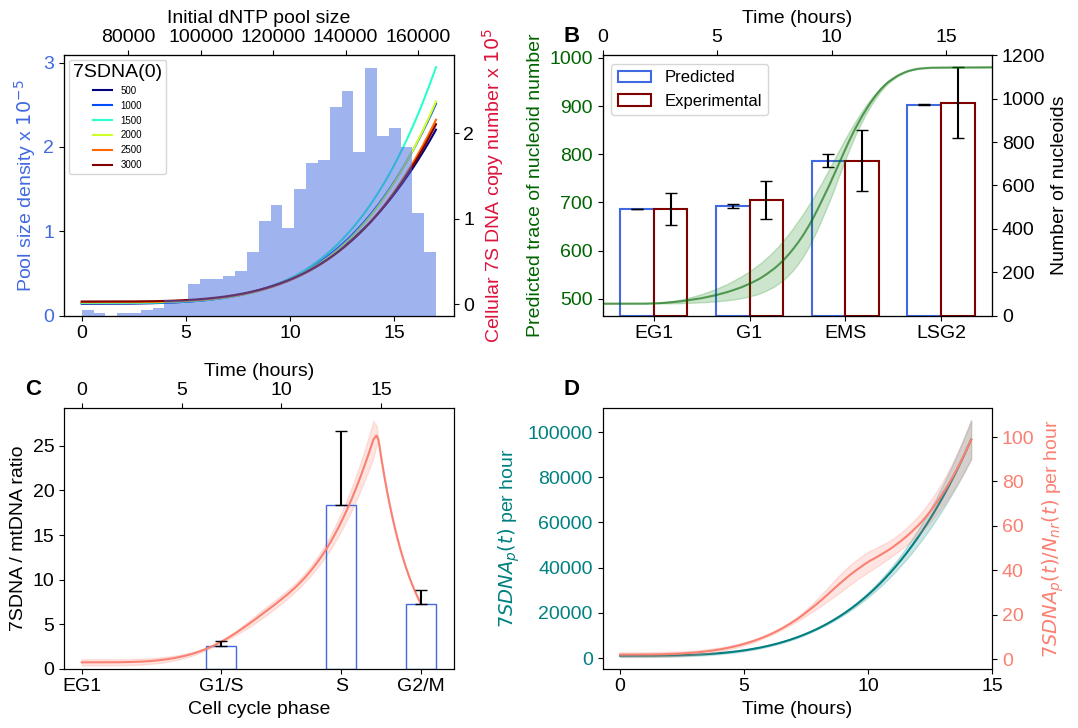

In [29]:
plot_figure_2(fits_df, results_by_rate, results_by_rate_nocutoff,F2_CELL_CYCLE_TIME,F2_DIST_TYPE)

### 7.2 Supplementary Figure S1

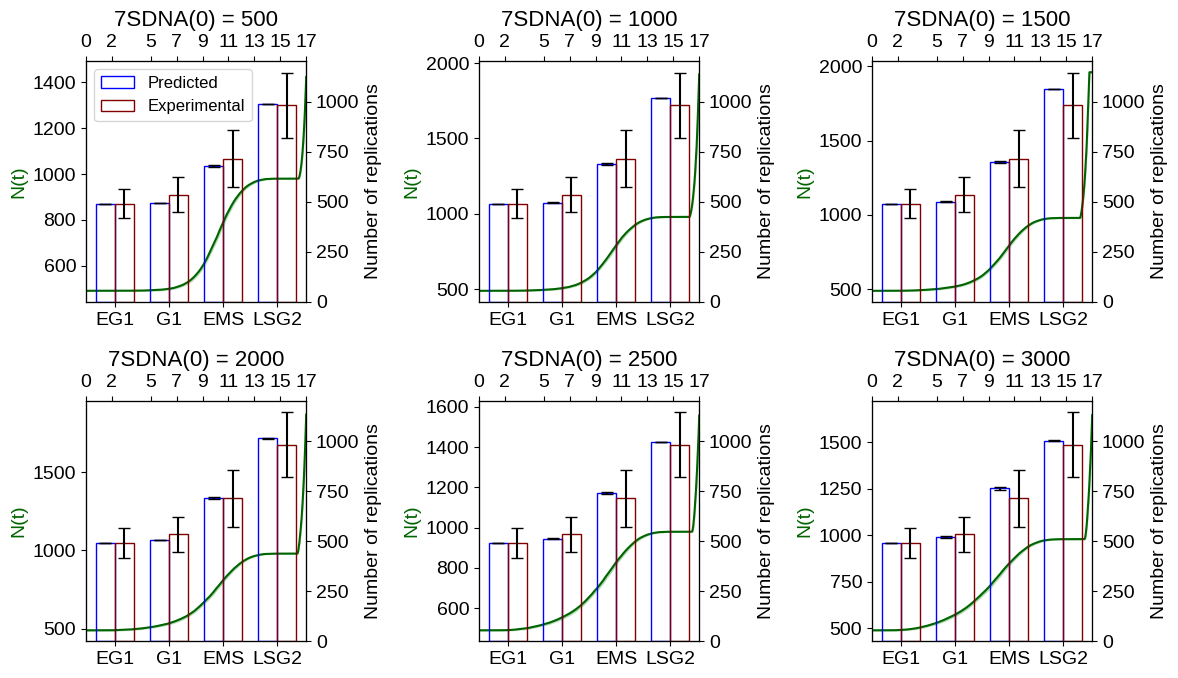

In [23]:
plot_sasaki_grid(results_by_rate_nocutoff, "", with_trace=True, filename="Figure_S1")

### 7.3 Supplementary Figure S2

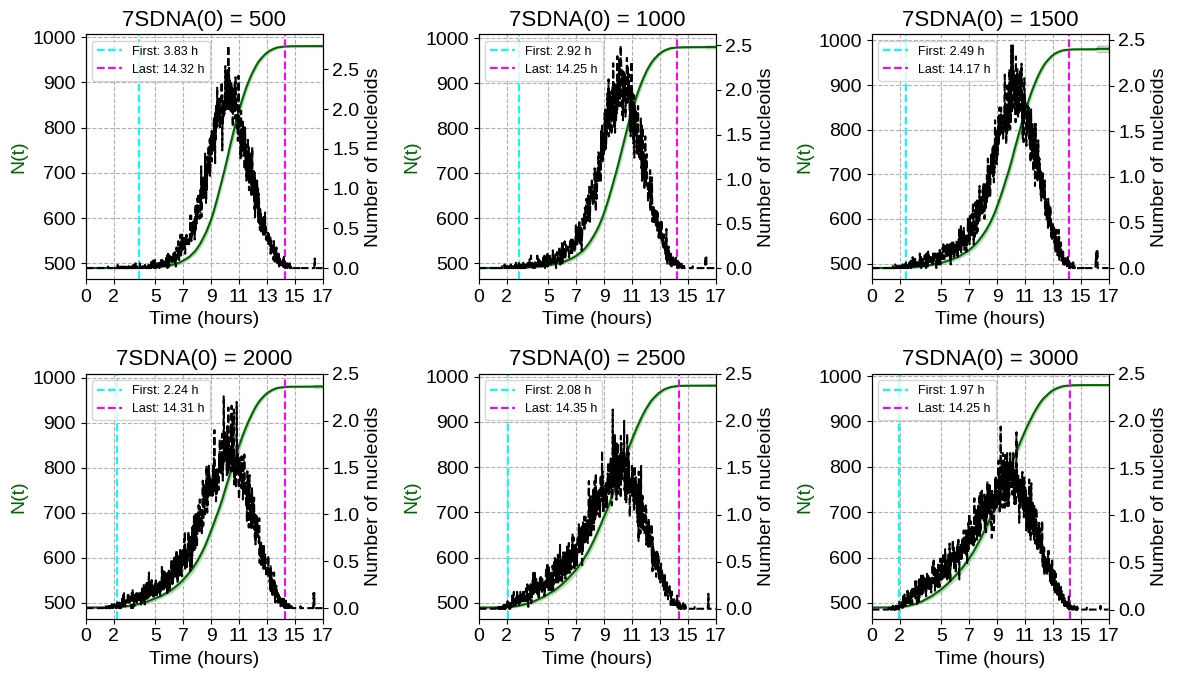

In [24]:
plot_traces_grid(results_by_rate, "", filename="Figure_S2")

### 7.4 Supplementary Figure S3

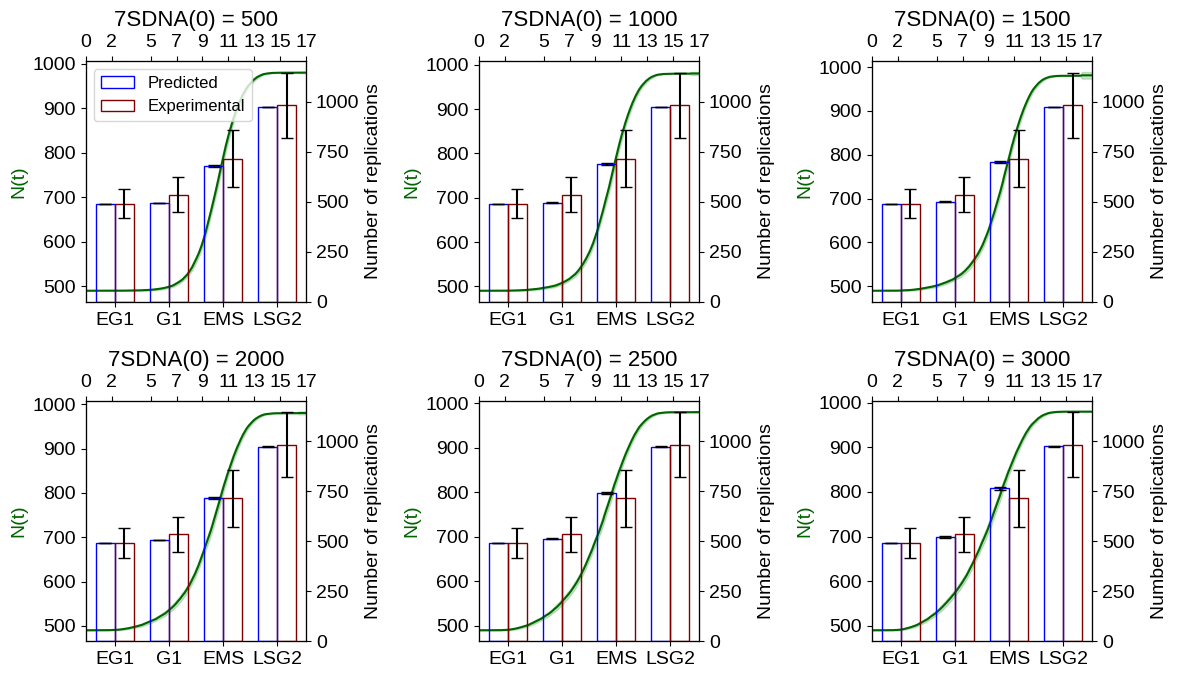

In [25]:
plot_sasaki_grid(results_by_rate, "", with_trace=True, filename="Figure_S3")

### 7.5 Supplementary Figure S7

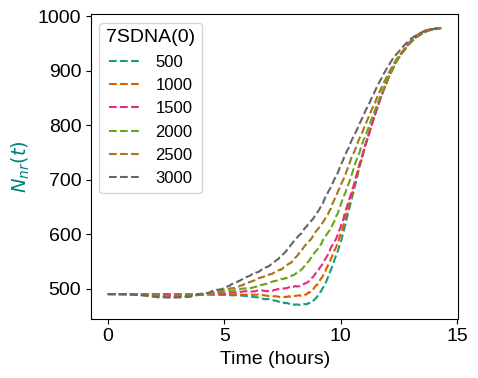

In [26]:
plot_Hungry(results_by_rate, filename="Figure_S7")

## 8. Execution: Figure 3 (HeLa/Cybrid)
Simulating mtDNA mass conservation with cybrid lines.


--- Running Figure 3 ---
Plotting Figure 3...


|   Strain |    Mean |      SD |
|---------:|--------:|--------:|
|     9049 | 2606.91 | 20.6753 |
|    16569 | 2606.92 | 20.7017 |
|    25323 | 2606.91 | 20.6746 |

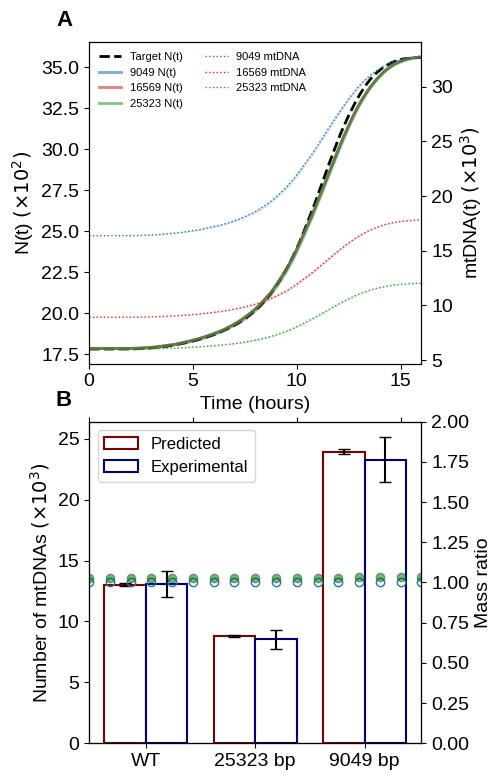

In [31]:
print("\n--- Running Figure 3 ---")
res_f3 = {}

fig3_fname = 'figures/figure3.pkl'
if not os.path.exists(fig3_fname):  
    for size in [16569, 25323, 9049]:
        args = []
        for p in F3_PARAMS:
            argsx = [(size, i, p) for i in range(NUM_REPLICATES)]
            args.extend(argsx)
        res_f3[size] = db.from_sequence(args).map(run_fig3_replicate).compute()
    with open(fig3_fname,'wb') as ser:
        pickle.dump(res_f3,ser)
else:
    with open(fig3_fname,'rb') as ser:
        res_f3 = pickle.load(ser)        
plot_figure_3(res_f3,sas_time_line,sas_mean_trace,sas_cutoff_time)


### Supplementary Figure S9

Generating Figure S9...


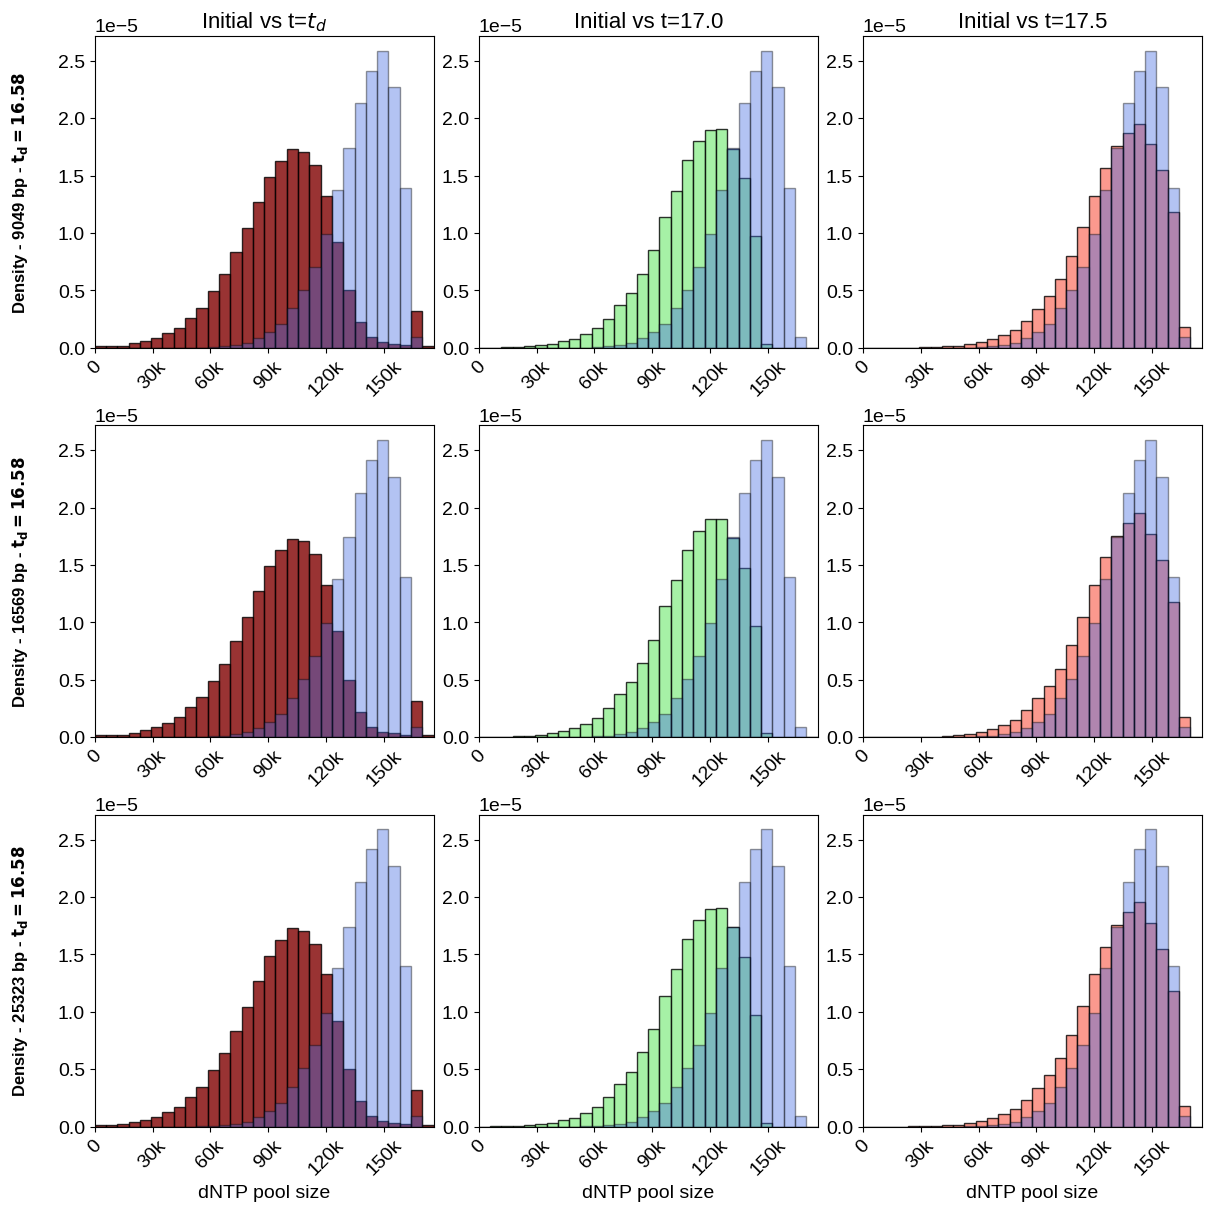

In [32]:
plot_figure_s9(res_f3)